This notebook mirrors the Colab file-system layout from experiment.ipynb; mount Drive before running and execute cells sequentially. Copy any reusable utilities back into experiment.ipynb once validated.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Core imports
import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import timm

plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
Image.MAX_IMAGE_PIXELS = None
tqdm.pandas()

In [3]:
# Paths shared with experiment.ipynb
DRIVE_ROOT = Path("/content/drive/MyDrive/ANNChallenges/SecondChallenge/an2dl2526c2")
TRAIN_DIR = DRIVE_ROOT / "train_data"
TEST_DIR = DRIVE_ROOT / "test_data"
TRAIN_LABELS_PATH = DRIVE_ROOT / "train_labels.csv"

if not TRAIN_LABELS_PATH.exists():
    raise FileNotFoundError(f"Expected labels at {TRAIN_LABELS_PATH}, but the file is missing.")

print(f"Train directory: {TRAIN_DIR}")
print(f"Test directory: {TEST_DIR}")
print(f"Labels CSV: {TRAIN_LABELS_PATH}")

Train directory: /content/drive/MyDrive/ANNChallenges/SecondChallenge/an2dl2526c2/train_data
Test directory: /content/drive/MyDrive/ANNChallenges/SecondChallenge/an2dl2526c2/test_data
Labels CSV: /content/drive/MyDrive/ANNChallenges/SecondChallenge/an2dl2526c2/train_labels.csv


## Load Metadata

In [4]:
labels_df = pd.read_csv(TRAIN_LABELS_PATH)
if "image_id" not in labels_df.columns:
    if "sample_index" in labels_df.columns:
        labels_df["image_id"] = labels_df["sample_index"].str.replace(".png", "", regex=False)
    else:
        raise KeyError("Expected either 'image_id' or 'sample_index' column in labels_df.")

labels_df["label"] = labels_df["label"].astype(str)
labels_df = labels_df.drop_duplicates("image_id").sort_values("image_id").reset_index(drop=True)
labels_df.head()

,sample_index,label,image_id
0,img_0000.png,Triple negative,img_0000
1,img_0001.png,Luminal B,img_0001
2,img_0002.png,Luminal B,img_0002
3,img_0003.png,Luminal B,img_0003
4,img_0004.png,Luminal B,img_0004


## Dataset Overview

In [5]:
num_samples = len(labels_df)
num_classes = labels_df["label"].nunique()
class_counts = labels_df["label"].value_counts().sort_index()
class_summary = (
    class_counts.rename("count").to_frame()
    .assign(fraction=lambda df: df["count"] / num_samples,
            percentage=lambda df: 100 * df["count"] / num_samples)
)

available_images = sum((TRAIN_DIR / f"{image_id}.png").exists() for image_id in labels_df["image_id"])
available_masks = sum((TRAIN_DIR / f"mask_{image_id.replace('img_', '')}.png").exists() for image_id in labels_df["image_id"])

print(f"Total labelled patches: {num_samples}")
print(f"Unique classes: {num_classes}")
print(f"Images present on disk: {available_images}")
print(f"Masks present on disk: {available_masks}")
class_summary

Total labelled patches: 691
Unique classes: 4
Images present on disk: 691
Masks present on disk: 691


,count,fraction,percentage
label,,,
HER2(+),189,0.273517,27.351664
Luminal A,205,0.296671,29.667149
Luminal B,220,0.318379,31.837916
Triple negative,77,0.111433,11.143271


### Class Distribution

/tmp/ipython-input-523460947.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis", ax=ax)


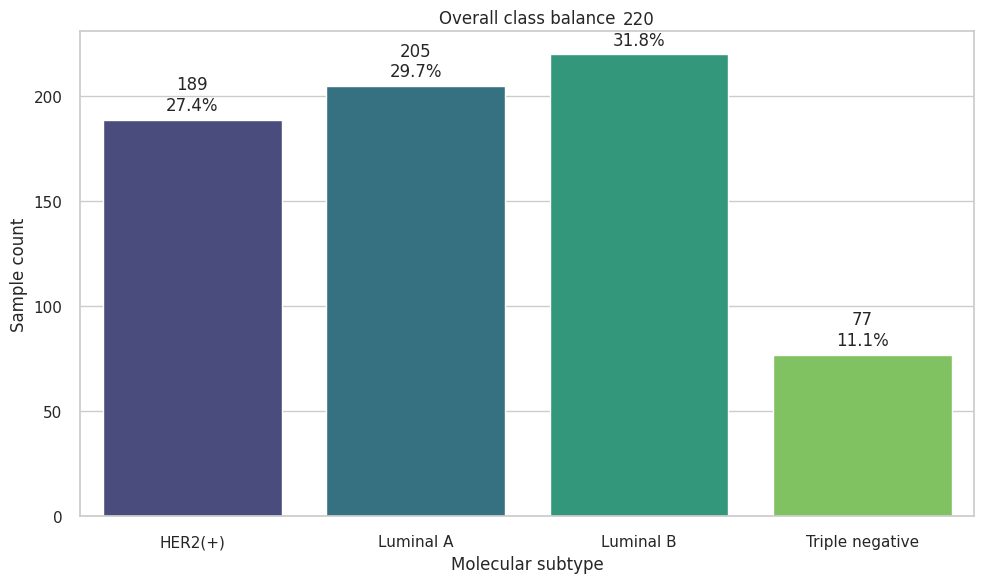

In [7]:
fig, ax = plt.subplots()
class_counts = labels_df["label"].value_counts().sort_index()
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis", ax=ax)
ax.set_xlabel("Molecular subtype")
ax.set_ylabel("Sample count")
ax.set_title("Overall class balance")
for container in ax.containers:
    ax.bar_label(container, labels=[f"{int(v)}\n{v / num_samples:.1%}" for v in container.datavalues], padding=4)
plt.tight_layout()
plt.show()

### Stratified Train/Validation Check

In [8]:
train_df, val_df = train_test_split(
    labels_df, test_size=0.2, random_state=42, stratify=labels_df["label"]
)

split_counts = (
    pd.concat([
        train_df.assign(split="train"),
        val_df.assign(split="val"),
    ])
    .groupby(["split", "label"]).size().rename("count").reset_index()
)
split_counts["fraction"] = split_counts.groupby("split")["count"].transform(lambda s: s / s.sum())
split_counts

,split,label,count,fraction
0,train,HER2(+),151,0.273551
1,train,Luminal A,164,0.297101
2,train,Luminal B,176,0.318841
3,train,Triple negative,61,0.110507
4,val,HER2(+),38,0.273381
5,val,Luminal A,41,0.294964
6,val,Luminal B,44,0.316547
7,val,Triple negative,16,0.115108


/tmp/ipython-input-3635506752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, x="label", y="count", palette="viridis", ax=ax)
/tmp/ipython-input-3635506752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, x="label", y="count", palette="viridis", ax=ax)


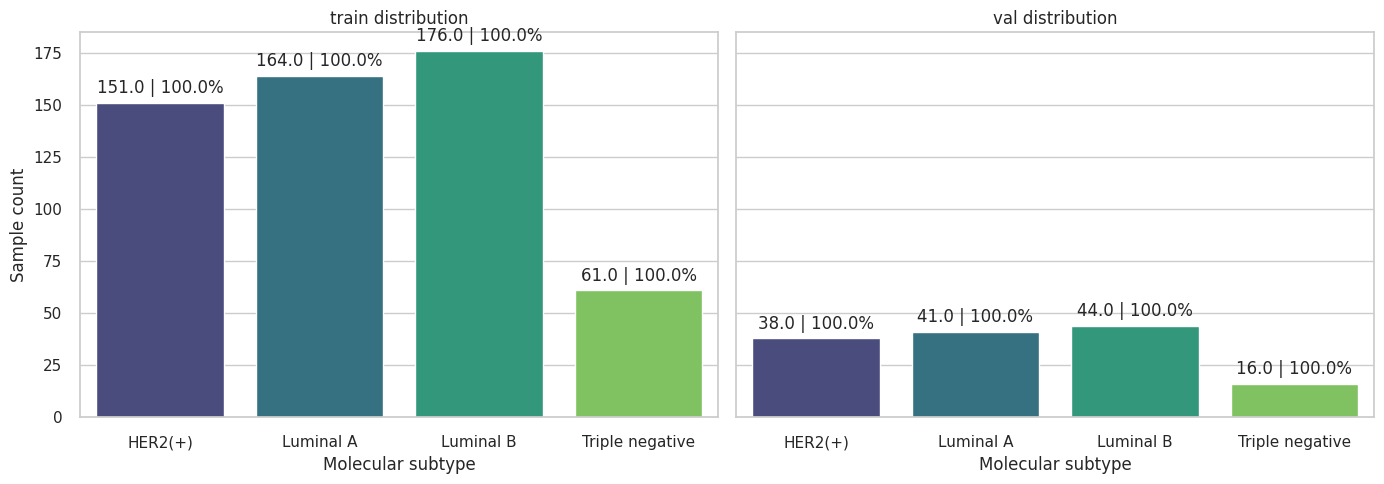

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (split_name, subset) in zip(axes, split_counts.groupby("split")):
    sns.barplot(data=subset, x="label", y="count", palette="viridis", ax=ax)
    ax.set_title(f"{split_name} distribution")
    ax.set_xlabel("Molecular subtype")
    ax.set_ylabel("Sample count")
    for container in ax.containers:
        ax.bar_label(container, labels=[f"{v} | {v / container.datavalues.sum():.1%}" for v in container.datavalues], padding=4)
plt.tight_layout()
plt.show()

## Spatial Properties (Resolution, Aspect Ratio, Mask Coverage)

In [10]:
def crop_to_mask(pil_img, pil_mask, margin=0.15):
    np_mask = np.array(pil_mask)
    foreground = np_mask > 0
    if not foreground.any():
        return pil_img, pil_mask
    coords = np.argwhere(foreground)
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    height = y_max - y_min + 1
    width = x_max - x_min + 1
    pad_h = int(round(height * margin))
    pad_w = int(round(width * margin))
    left = max(0, x_min - pad_w)
    upper = max(0, y_min - pad_h)
    right = min(pil_mask.width, x_max + pad_w + 1)
    lower = min(pil_mask.height, y_max + pad_h + 1)
    return pil_img.crop((left, upper, right, lower)), pil_mask.crop((left, upper, right, lower))

def compute_spatial_stats(df, limit=None):
    subset = df if limit is None else df.sample(min(limit, len(df)), random_state=42)
    records = []
    for row in tqdm(subset.itertuples(), total=len(subset), desc="Collecting spatial stats"):
        image_id = row.image_id
        image_path = TRAIN_DIR / f"{image_id}.png"
        mask_path = TRAIN_DIR / f"mask_{image_id.replace('img_', '')}.png"
        if not image_path.exists():
            continue
        with Image.open(image_path) as img:
            width, height = img.size
        mask_coverage = np.nan
        if mask_path.exists():
            with Image.open(mask_path) as mask_img:
                mask_array = np.array(mask_img)
            mask_coverage = float((mask_array > 0).mean())
        records.append({
            "image_id": image_id,
            "label": row.label,
            "width": width,
            "height": height,
            "aspect_ratio": width / height,
            "area": width * height,
            "mask_coverage": mask_coverage,
        })
    return pd.DataFrame(records)

spatial_stats = compute_spatial_stats(labels_df)
spatial_stats.describe().T

,count,mean,std,min,25%,50%,75%,max
width,691.0,1.220456e+03,417.012278,1.024000e+03,1.024000e+03,1.024000e+03,1.258000e+03,3.914000e+03
height,691.0,1.355669e+03,526.074761,1.024000e+03,1.024000e+03,1.100000e+03,1.484000e+03,4.233000e+03
aspect_ratio,691.0,1.022262e+00,0.523175,2.419088e-01,6.900270e-01,9.309091e-01,1.228516e+00,3.822266e+00
area,691.0,1.589375e+06,579396.311393,1.048576e+06,1.190400e+06,1.419264e+06,1.785856e+06,4.334592e+06
mask_coverage,691.0,1.889455e-02,0.020865,1.247690e-03,6.364603e-03,1.070584e-02,2.161392e-02,1.396398e-01


/tmp/ipython-input-4044297707.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=spatial_stats, x="label", y="mask_coverage", palette="viridis", ax=axes[1, 1])


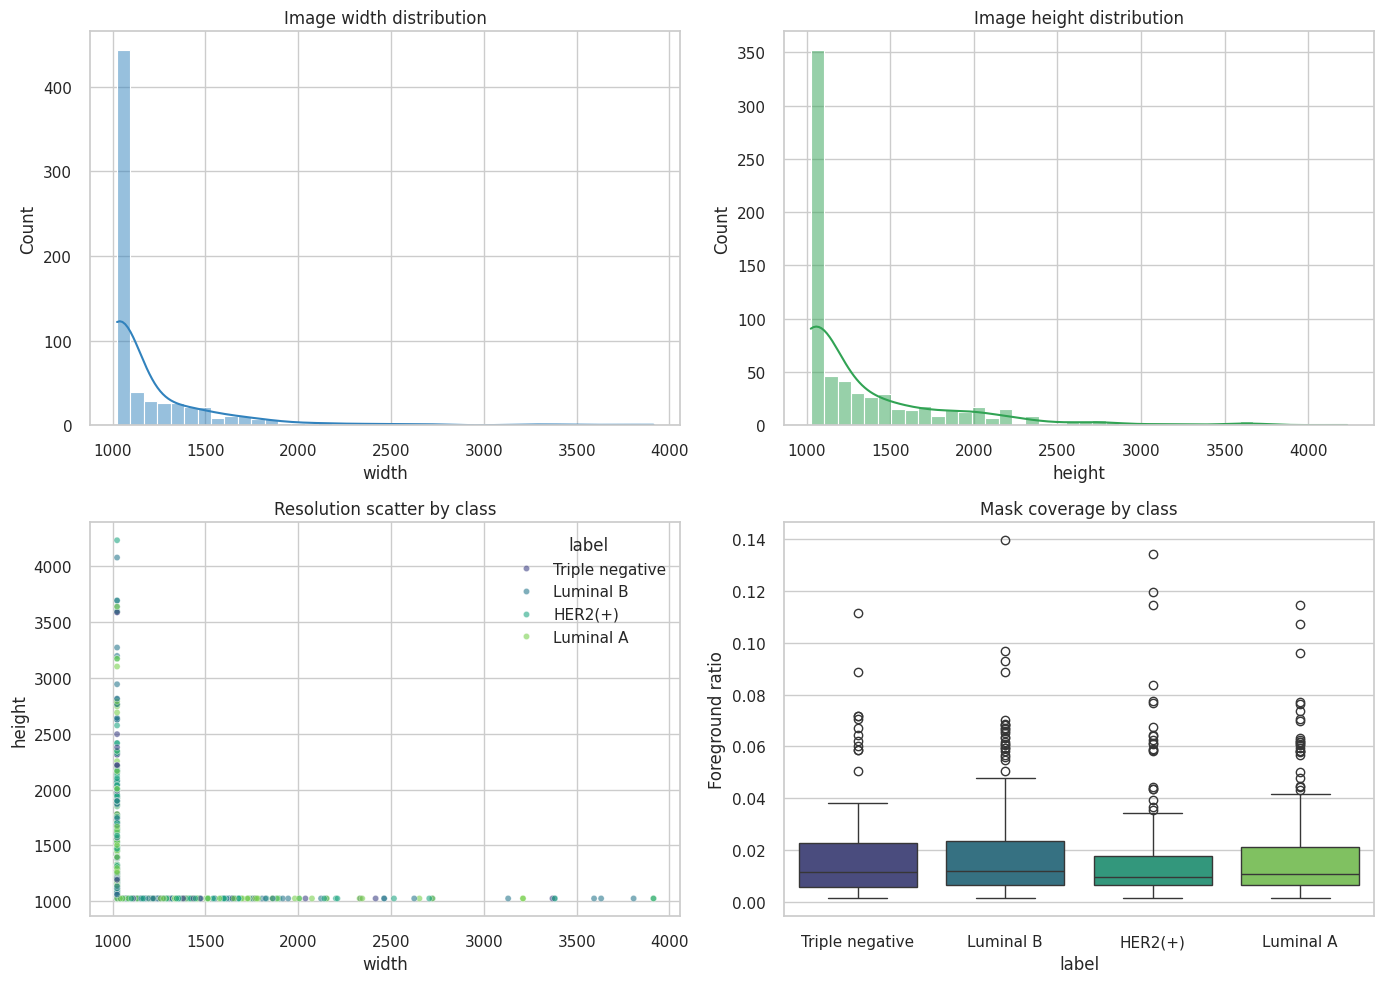

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(spatial_stats, x="width", bins=40, ax=axes[0, 0], kde=True, color="#3182bd")
axes[0, 0].set_title("Image width distribution")
sns.histplot(spatial_stats, x="height", bins=40, ax=axes[0, 1], kde=True, color="#31a354")
axes[0, 1].set_title("Image height distribution")
sns.scatterplot(data=spatial_stats, x="width", y="height", hue="label", palette="viridis", ax=axes[1, 0], s=20, alpha=0.6)
axes[1, 0].set_title("Resolution scatter by class")
sns.boxplot(data=spatial_stats, x="label", y="mask_coverage", palette="viridis", ax=axes[1, 1])
axes[1, 1].set_title("Mask coverage by class")
axes[1, 1].set_ylabel("Foreground ratio")
plt.tight_layout()
plt.show()

## Channel Intensity & Stain Statistics

In [12]:
def compute_intensity_stats(df, sample_size=512):
    subset = df.sample(min(sample_size, len(df)), random_state=42)
    records = []
    for row in tqdm(subset.itertuples(), total=len(subset), desc="Collecting intensity stats"):
        image_path = TRAIN_DIR / f"{row.image_id}.png"
        if not image_path.exists():
            continue
        with Image.open(image_path) as img:
            arr = np.array(img).astype(np.float32) / 255.0
        channel_means = arr.mean(axis=(0, 1))
        channel_stds = arr.std(axis=(0, 1))
        records.append({
            "image_id": row.image_id,
            "label": row.label,
            "r_mean": channel_means[0],
            "g_mean": channel_means[1],
            "b_mean": channel_means[2],
            "r_std": channel_stds[0],
            "g_std": channel_stds[1],
            "b_std": channel_stds[2],
        })
    return pd.DataFrame(records)

intensity_stats = compute_intensity_stats(labels_df, sample_size=512)
intensity_stats.head()

,image_id,label,r_mean,g_mean,b_mean,r_std,g_std,b_std
0,img_0380,HER2(+),0.713300,0.702726,0.679424,0.090634,0.110701,0.148502
1,img_0675,Luminal A,0.699544,0.703000,0.682285,0.104472,0.112870,0.149097
2,img_0257,Triple negative,0.735119,0.728984,0.728054,0.046713,0.066493,0.042373
3,img_0338,Luminal B,0.728187,0.717855,0.718607,0.047892,0.069824,0.042783
4,img_0319,Luminal A,0.660863,0.649292,0.585567,0.159360,0.169415,0.249476


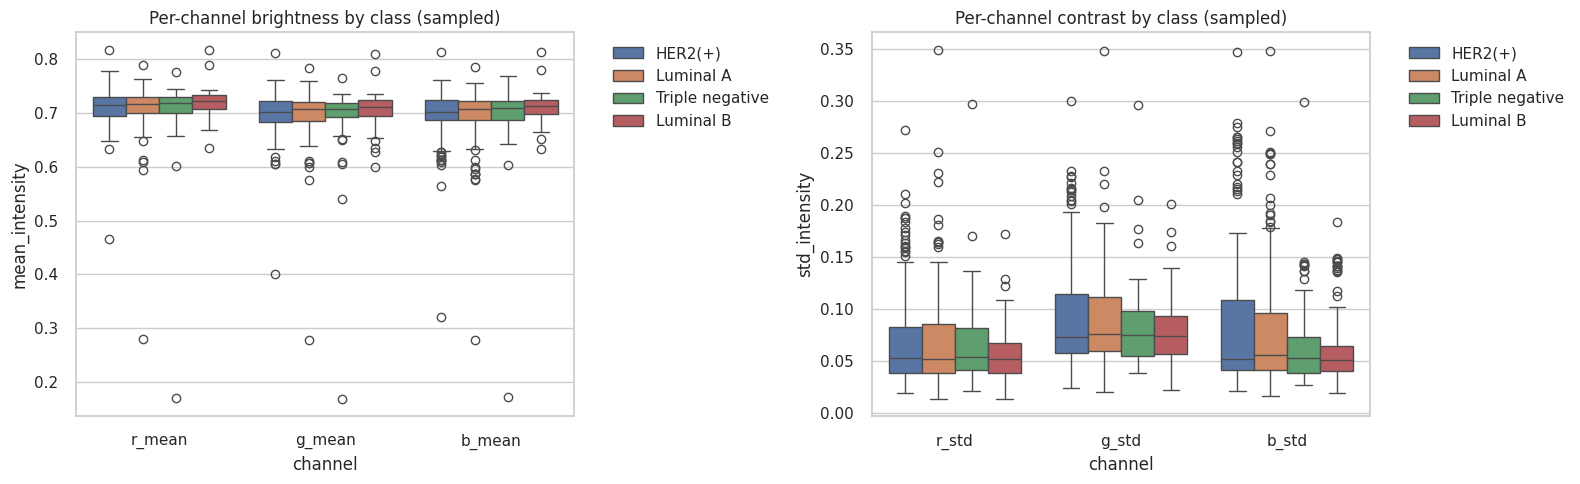

In [13]:
melt_means = intensity_stats.melt(id_vars=["image_id", "label"], value_vars=["r_mean", "g_mean", "b_mean"], var_name="channel", value_name="mean_intensity")
melt_stds = intensity_stats.melt(id_vars=["image_id", "label"], value_vars=["r_std", "g_std", "b_std"], var_name="channel", value_name="std_intensity")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=melt_means, x="channel", y="mean_intensity", hue="label", ax=axes[0])
axes[0].set_title("Per-channel brightness by class (sampled)")
sns.boxplot(data=melt_stds, x="channel", y="std_intensity", hue="label", ax=axes[1])
axes[1].set_title("Per-channel contrast by class (sampled)")
for ax in axes:
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

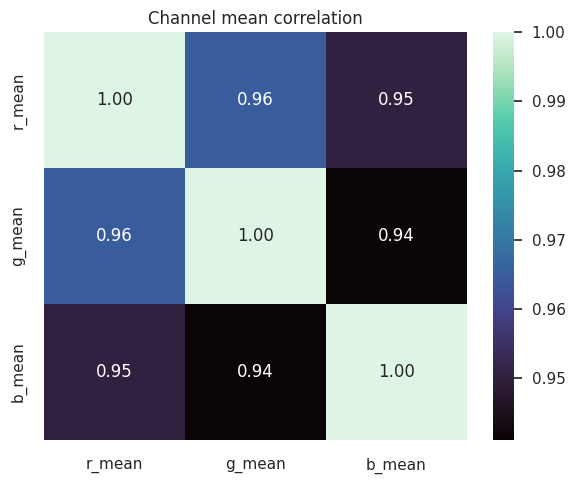

In [14]:
corr_mat = intensity_stats[["r_mean", "g_mean", "b_mean"]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="mako", ax=ax)
ax.set_title("Channel mean correlation")
plt.tight_layout()
plt.show()

### Optional: H&E Stain Decomposition (run if scikit-image is installed)

In [15]:
try:
    from skimage.color import separate_stains, hed_from_rgb
except ImportError as exc:
    raise ImportError("Install scikit-image to enable stain decomposition analysis.") from exc

def compute_stain_intensity(df, sample_size=256):
    subset = df.sample(min(sample_size, len(df)), random_state=42)
    records = []
    for row in tqdm(subset.itertuples(), total=len(subset), desc="Collecting H&E stats"):
        image_path = TRAIN_DIR / f"{row.image_id}.png"
        if not image_path.exists():
            continue
        with Image.open(image_path) as img:
            arr = np.array(img).astype(np.float32) / 255.0
        hed = separate_stains(arr, hed_from_rgb)
        records.append({
            "image_id": row.image_id,
            "label": row.label,
            "hematoxylin_mean": hed[..., 0].mean(),
            "eosin_mean": hed[..., 1].mean(),
            "dab_mean": hed[..., 2].mean(),
        })
    return pd.DataFrame(records)

stain_stats = compute_stain_intensity(labels_df, sample_size=256)
stain_stats.head()

,image_id,label,hematoxylin_mean,eosin_mean,dab_mean
0,img_0380,HER2(+),0.026111,0.001678,0.066942
1,img_0675,Luminal A,0.030188,0.000586,0.065511
2,img_0257,Triple negative,0.027203,0.000055,0.021064
3,img_0338,Luminal B,0.028030,0.000101,0.022037
4,img_0319,Luminal A,0.030122,0.000001,0.059251


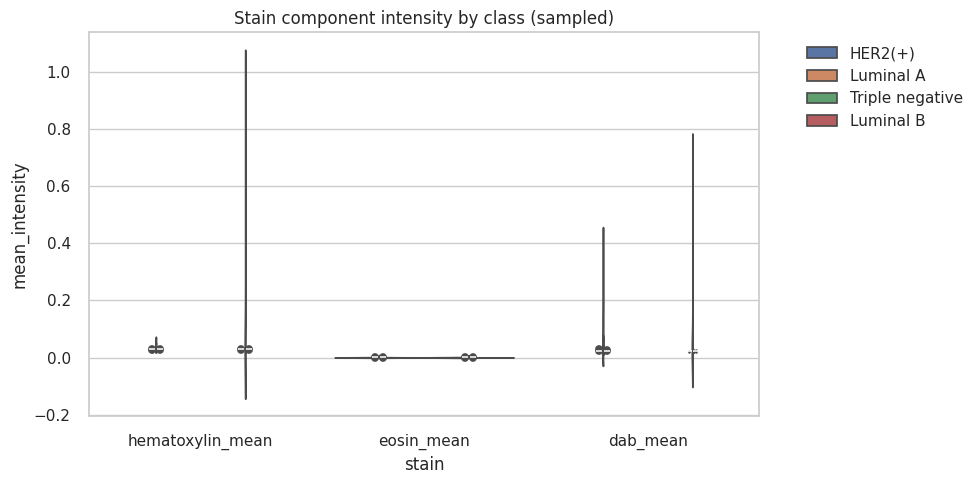

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
melt_stain = stain_stats.melt(id_vars=["image_id", "label"], value_vars=["hematoxylin_mean", "eosin_mean", "dab_mean"], var_name="stain", value_name="mean_intensity")
sns.violinplot(data=melt_stain, x="stain", y="mean_intensity", hue="label", split=True, ax=ax)
ax.set_title("Stain component intensity by class (sampled)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Sample Grids

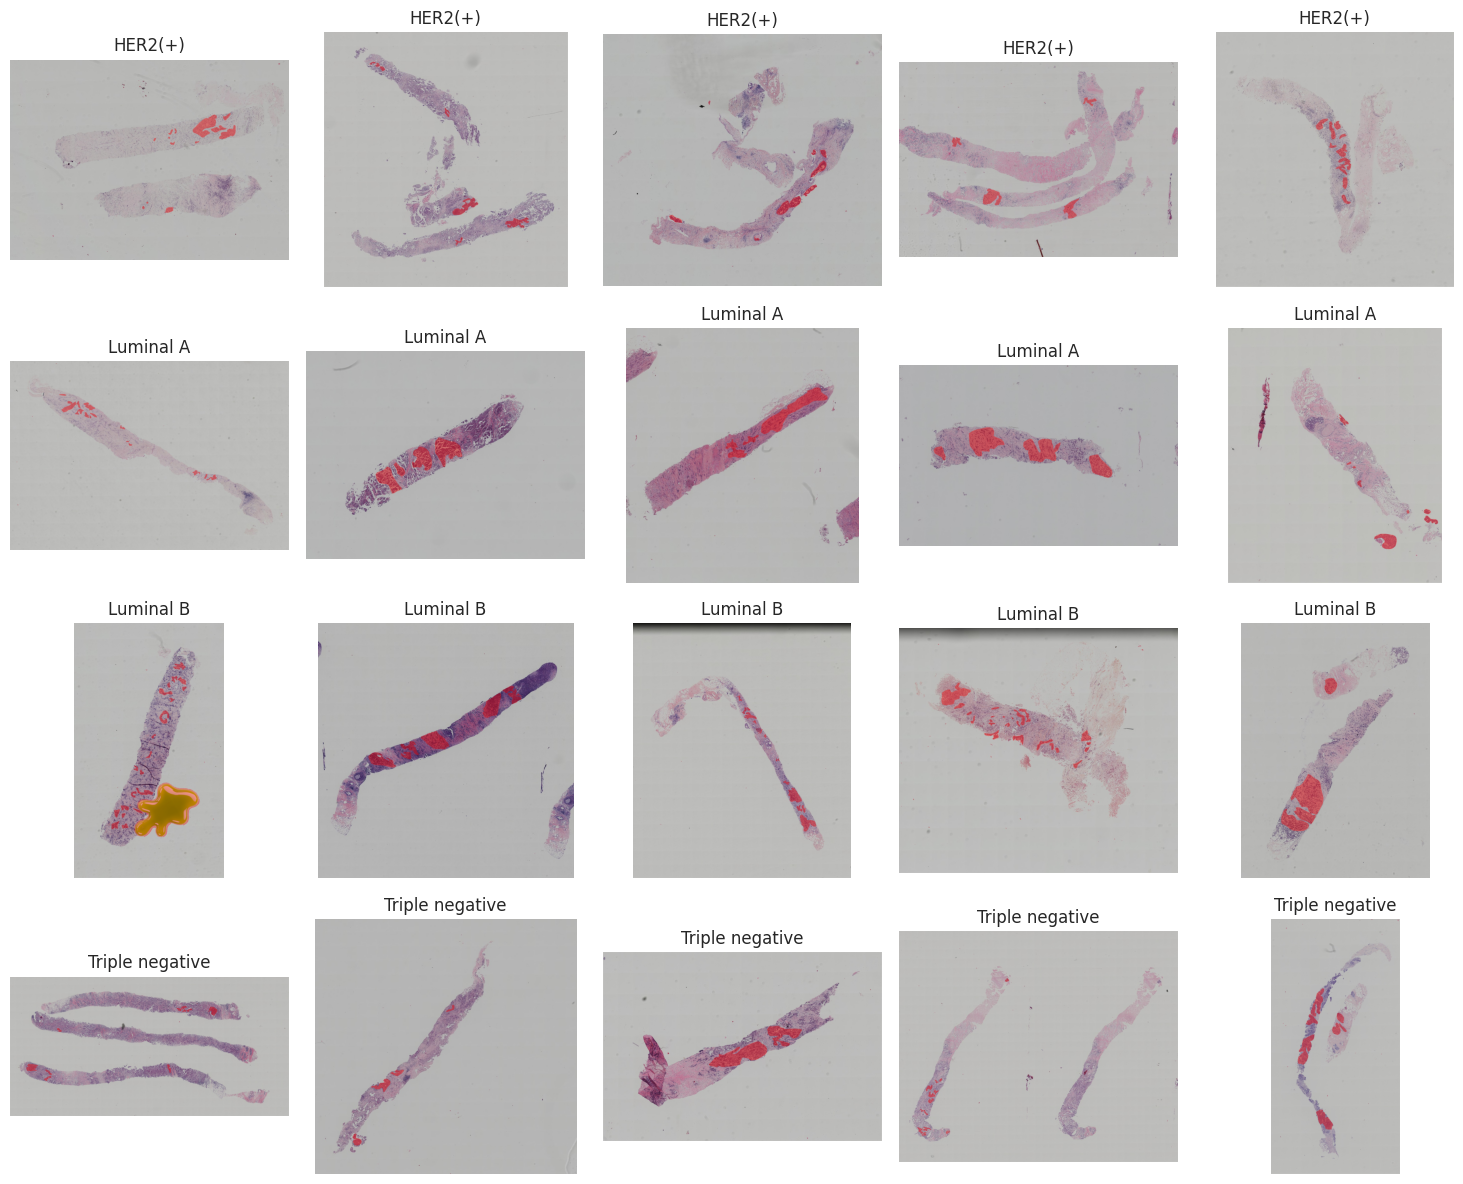

In [17]:
def show_class_grid(df, n_per_class=6, random_state_value=42):
    rng = np.random.default_rng(random_state_value)
    labels = sorted(df["label"].unique())
    fig_rows = len(labels)
    fig_cols = n_per_class
    fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(3 * fig_cols, 3 * fig_rows))
    if fig_rows == 1:
        axes = np.expand_dims(axes, axis=0)
    for row_idx, label in enumerate(labels):
        candidates = df[df["label"] == label]
        sampled = candidates.sample(n=min(n_per_class, len(candidates)), random_state=random_state_value)
        for col_idx, (_, sample) in enumerate(sampled.iterrows()):
            ax = axes[row_idx, col_idx]
            image_path = TRAIN_DIR / f"{sample.image_id}.png"
            mask_path = TRAIN_DIR / f"mask_{sample.image_id.replace('img_', '')}.png"
            with Image.open(image_path) as img:
                img_to_show = img.copy()
            if mask_path.exists():
                with Image.open(mask_path) as mask_img:
                    mask_arr = np.array(mask_img) > 0
                overlay = np.array(img_to_show).astype(np.float32)
                overlay[mask_arr] = 0.6 * overlay[mask_arr] + 0.4 * np.array([255, 0, 0])
                img_to_show = Image.fromarray(overlay.astype(np.uint8))
            ax.imshow(img_to_show)
            ax.set_title(label)
            ax.axis("off")
    plt.tight_layout()
    plt.show()

show_class_grid(labels_df, n_per_class=5)

## Augmentation Sanity Check

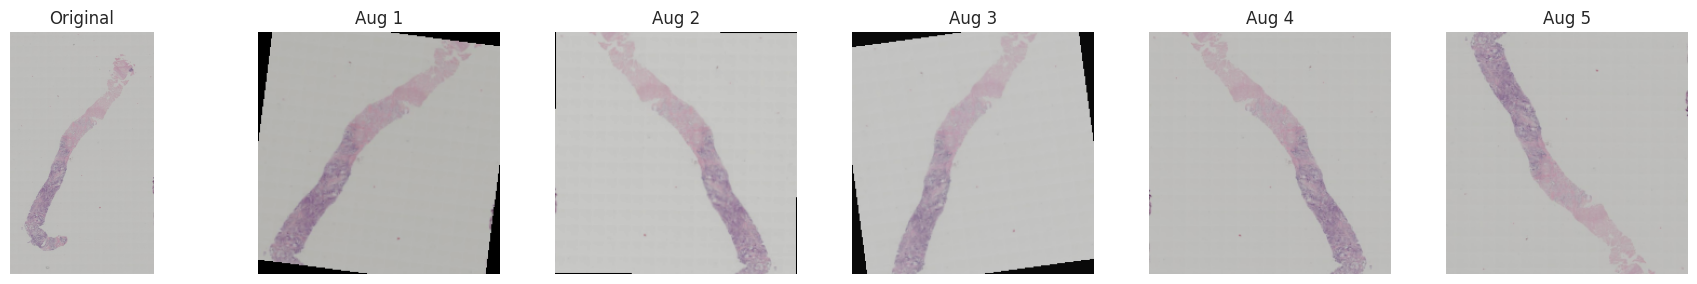

In [20]:
IMG_SIZE = 224
COLOR_JITTER = T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02)

def apply_training_transforms(img, mask, rotation_prob=0.7, use_color_jitter=True, color_jitter_prob=0.7):
    i, j, h, w = T.RandomResizedCrop.get_params(img, scale=(0.7, 1.0), ratio=(0.9, 1.1))
    img = TF.resized_crop(img, i, j, h, w, (IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.BILINEAR)
    mask = TF.resized_crop(mask, i, j, h, w, (IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.NEAREST)
    if random.random() < 0.5:
        img = TF.hflip(img); mask = TF.hflip(mask)
    if random.random() < 0.5:
        img = TF.vflip(img); mask = TF.vflip(mask)
    if random.random() < rotation_prob:
        angle = random.uniform(-15, 15)
        img = TF.rotate(img, angle, interpolation=T.InterpolationMode.BILINEAR)
        mask = TF.rotate(mask, angle, fill=0, interpolation=T.InterpolationMode.NEAREST)
    if use_color_jitter and random.random() < color_jitter_prob:
        img = COLOR_JITTER(img)
    return img, mask

def preview_augmentations(image_id, samples=6, seed=0):
    rng = random.Random(seed)
    random.seed(seed)
    image_path = TRAIN_DIR / f"{image_id}.png"
    mask_path = TRAIN_DIR / f"mask_{image_id.replace('img_', '')}.png"
    with Image.open(image_path) as img:
        base_img = img.convert("RGB")
    if mask_path.exists():
        with Image.open(mask_path) as mask_img:
            base_mask = mask_img.convert("L")
        base_img, base_mask = crop_to_mask(base_img, base_mask, margin=0.2)
    else:
        base_mask = Image.new("L", base_img.size, color=255)
    fig, axes = plt.subplots(1, samples + 1, figsize=(3 * (samples + 1), 3))
    axes[0].imshow(base_img)
    axes[0].set_title("Original")
    axes[0].axis("off")
    for idx in range(1, samples + 1):
        aug_img, _ = apply_training_transforms(base_img, base_mask)
        axes[idx].imshow(aug_img)
        axes[idx].set_title(f"Aug {idx}")
        axes[idx].axis("off")
    plt.tight_layout()
    plt.show()

preview_target = labels_df.loc[0, "image_id"]
preview_augmentations(preview_target, samples=5)

## Embedding Projections

In [21]:
def build_feature_extractor(model_name="efficientnet_b0"):
    model = timm.create_model(model_name, pretrained=True, num_classes=0, global_pool="avg")
    model.eval()
    return model

EVAL_TRANSFORM = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def preprocess_image(image_id):
    image_path = TRAIN_DIR / f"{image_id}.png"
    mask_path = TRAIN_DIR / f"mask_{image_id.replace('img_', '')}.png"
    with Image.open(image_path) as img:
        img = img.convert("RGB")
    if mask_path.exists():
        with Image.open(mask_path) as mask_img:
            img, _ = crop_to_mask(img, mask_img.convert("L"), margin=0.2)
    return EVAL_TRANSFORM(img)

def extract_embeddings(df, sample_size=256, batch_size=32, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    subset = df.sample(min(sample_size, len(df)), random_state=42).reset_index(drop=True)
    model = build_feature_extractor().to(device)
    feats = []
    with torch.no_grad():
        for start in tqdm(range(0, len(subset), batch_size), desc="Embedding batches"):
            end = start + batch_size
            batch = subset.iloc[start:end]
            tensors = torch.stack([preprocess_image(row.image_id) for row in batch.itertuples()])
            tensors = tensors.to(device)
            outputs = model(tensors)
            feats.append(outputs.cpu().numpy())
    features = np.concatenate(feats, axis=0)
    return subset.reset_index(drop=True), features

embedding_subset, embedding_features = extract_embeddings(labels_df, sample_size=256, batch_size=32)
embedding_features.shape

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Embedding batches:   0%|          | 0/8 [00:00<?, ?it/s]

(256, 1280)

In [22]:
pca = PCA(n_components=2, random_state=42)
pca_proj = pca.fit_transform(embedding_features)
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42, init="pca")
tsne_proj = tsne.fit_transform(embedding_features)

proj_df = pd.DataFrame({
    "label": embedding_subset["label"],
    "pca_x": pca_proj[:, 0],
    "pca_y": pca_proj[:, 1],
    "tsne_x": tsne_proj[:, 0],
    "tsne_y": tsne_proj[:, 1],
})
proj_df.head()

,label,pca_x,pca_y,tsne_x,tsne_y
0,HER2(+),-8.260928,-8.401245,12.922249,-10.352344
1,Luminal A,-7.899940,-6.834996,-9.511522,3.533448
2,Triple negative,5.169533,-1.510218,-8.453738,-7.848774
3,Luminal B,3.527208,-1.016968,-6.207461,-4.679498
4,Luminal A,-7.310450,-7.153591,-11.683476,10.468435


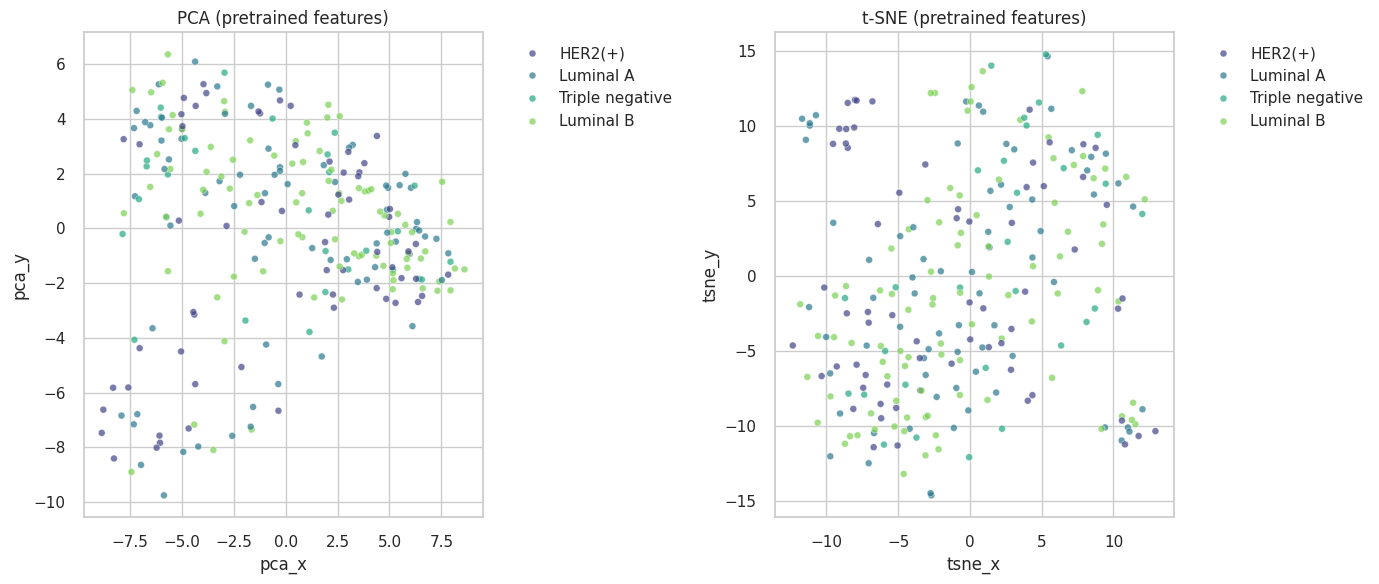

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=proj_df, x="pca_x", y="pca_y", hue="label", palette="viridis", ax=axes[0], s=25, alpha=0.7)
axes[0].set_title("PCA (pretrained features)")
sns.scatterplot(data=proj_df, x="tsne_x", y="tsne_y", hue="label", palette="viridis", ax=axes[1], s=25, alpha=0.7)
axes[1].set_title("t-SNE (pretrained features)")
for ax in axes:
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Next Steps

- Export tables (class_summary, spatial_stats, intensity_stats) as CSV for quick reference.
- Integrate stratified split, augmentation previews, and feature embeddings back into experiment.ipynb after validation.
- Extend with confusion matrices once validation predictions are available.